# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>04 - CNN - CIFAR</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b> DATA SCIENCE - CNN & CV LESSON                      </b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [Whatsapp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [Linkedin](https://www.linkedin.com/company/techproeducation/mycompany/) |

**This notebook will develop a prediction model using the famous CIFAR dataset. The model will be developed in 4 stages.**

NOTE: When running the code lines here (especially the parts where the model is FIT) locally, the Epoch progress might not be at the desired level. The solution here gave better results when run in COLAB. Let’s show that version.

![image.png](attachment:image.png)

![image.png](attachment:image.png)

https://medium.com/academy-team/derin-%C3%B6%C4%9Frenme-modellerinin-e%C4%9Fitiminde-kullan%C4%B1lan-5-%C3%B6nemli-veri-seti-788a1d71f9fd

![image.png](attachment:image.png)

In [1]:
import tensorflow as tf

In [2]:
import pandas as pd
import seaborn as sns
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# EDA

## Load Data

In [3]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
print("There are ", len(X_train), "images in the training dataset")
print("There are ", len(X_test), "images in the test dataset")

There are  50000 images in the training dataset
There are  10000 images in the test dataset


The CIFAR-10 dataset (Additionally there is CIFAR 100, There are 100 classes).

CIFAR: Canadian Institute For Advanced Research

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50,000 training images and 10,000 test images.

The dataset is divided into five training batches and one test batch, each with 10,000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.

CIFAR data set is ready to use, **spllitted to train and test**.

In [5]:
# check the shape of training and test datasets

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


* 3 for RGB (coloured).

In [6]:
# Checking the shape of one image
X_train[5].shape
# Input Shape

(32, 32, 3)

array([[[159, 102, 101],
        [150,  91,  95],
        [153,  95,  97],
        ...,
        [ 91,  71,  56],
        [ 74,  63,  55],
        [ 76,  58,  55]],

       [[142,  75,  68],
        [146,  72,  66],
        [155,  76,  65],
        ...,
        [127, 105,  71],
        [122, 111,  93],
        [ 86,  69,  61]],

       [[109,  67,  75],
        [ 99,  58,  60],
        [105,  59,  52],
        ...,
        [137, 112,  80],
        [163, 132, 105],
        [ 93,  72,  71]],

       ...,

       [[244, 129,  70],
        [240, 123,  65],
        [241, 122,  65],
        ...,
        [156,  42,  15],
        [179,  59,  26],
        [200,  73,  36]],

       [[246, 133,  74],
        [243, 128,  72],
        [243, 127,  70],
        ...,
        [162,  44,  14],
        [178,  56,  22],
        [192,  65,  27]],

       [[246, 139,  82],
        [243, 133,  78],
        [244, 132,  77],
        ...,
        [166,  47,  14],
        [173,  51,  17],
        [182,  57,  19]]], dtype=uint8)
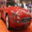

In [7]:
X_train[5] # Sometimes we may meet numericial forms of dataset. For this reason we should look our data first.

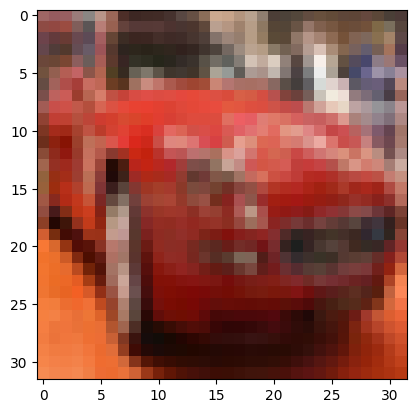

In [8]:
plt.imshow(X_train[5]);
# It is not desired for the images here to be large and have higher resolution, as the processing time will increase.
# Additionally, the computer will already recognize them from the edges.

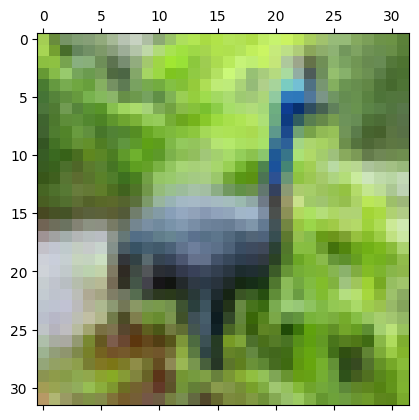

In [9]:
plt.matshow(X_train[6]);

In [10]:
y_train[5] # Index 1 image is a car in our data set.

array([1], dtype=uint8)

In [11]:
y_train.shape

(50000, 1)

**What are Scalar and Vector quantities?**

Physical quantities that can only be expressed by their magnitude, such as mass, temperature, energy, and time, are called "scalar quantities." Some quantities commonly used in physics, such as velocity and force, differ from scalar quantities; in addition to their magnitudes, they also have directions. Quantities like velocity and force, which have both direction and magnitude, are referred to as "vector quantities."


In [12]:
y_train  # These are all scalar values, if we give them to the model like this, the model thinks this is a regression problem.

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [13]:
np.unique(y_train, return_counts=True)   # Unique values within the array are shown.
# return_counts= True  -->  You have also seen the numbers of these values by using this code.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]))

**Class names:**

- 0: Airplane
- 1: Automobile
- 2: Bird
- 3: Cat
- 4: Deer
- 5: Dog
- 6: Frog
- 7: Horse
- 8: Ship
- 9: Truck

In [14]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"] # We assigned class names to understand easily at prediction section.

In [15]:
y_train[3]

array([4], dtype=uint8)

In [16]:
classes[int(y_train[3])]   # We can indexed it

'deer'

In [17]:
int(np.random.randint(low=0, high=50000, size=1))  # Will return a random number between 0 and 50,000. (I'm explain "randit" usage)

11530

In [18]:
np.random.randint(low=0, high=50000, size=17)

array([38456, 41758, 29019, 44558, 12447, 36878, 40410, 23094, 16394,
       41581,  5104, 35287, 18521, 16039, 23348, 25076, 28887])

In [20]:
np.random.randint(low=0, high=50000, size=17) # We see different numbers each time.

array([30552, 30544, 12063, 18773, 36072, 29075,  2006, 12679, 39265,
       48250, 24359, 42629, 21937, 47143, 28723, 23508, 34178])

array([[[ 94,  90,  66],
        [ 78,  70,  50],
        [ 78,  67,  50],
        ...,
        [161, 159, 150],
        [124, 127, 101],
        [109, 119,  89]],

       [[ 80,  73,  50],
        [ 70,  59,  40],
        [ 75,  62,  45],
        ...,
        [144, 146, 141],
        [105, 111,  92],
        [ 82,  92,  73]],

       [[ 81,  72,  47],
        [ 75,  62,  43],
        [ 69,  53,  37],
        ...,
        [126, 133, 132],
        [110, 119, 109],
        [ 62,  71,  61]],

       ...,

       [[ 89, 101, 110],
        [ 46,  56,  60],
        [ 14,  21,  21],
        ...,
        [128, 134, 134],
        [129, 137, 139],
        [131, 144, 150]],

       [[ 73,  85,  93],
        [ 37,  47,  49],
        [ 11,  18,  15],
        ...,
        [134, 139, 143],
        [134, 142, 146],
        [134, 147, 153]],

       [[ 79,  91,  99],
        [ 44,  55,  56],
        [ 24,  32,  27],
        ...,
        [139, 144, 152],
        [138, 145, 152],
        [136, 149, 155]]], dtype=uint8)
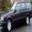

In [24]:
X_train[int(np.random.randint(low=0, high=50000, size=1))]   # It chooses a picture from X Train at random.

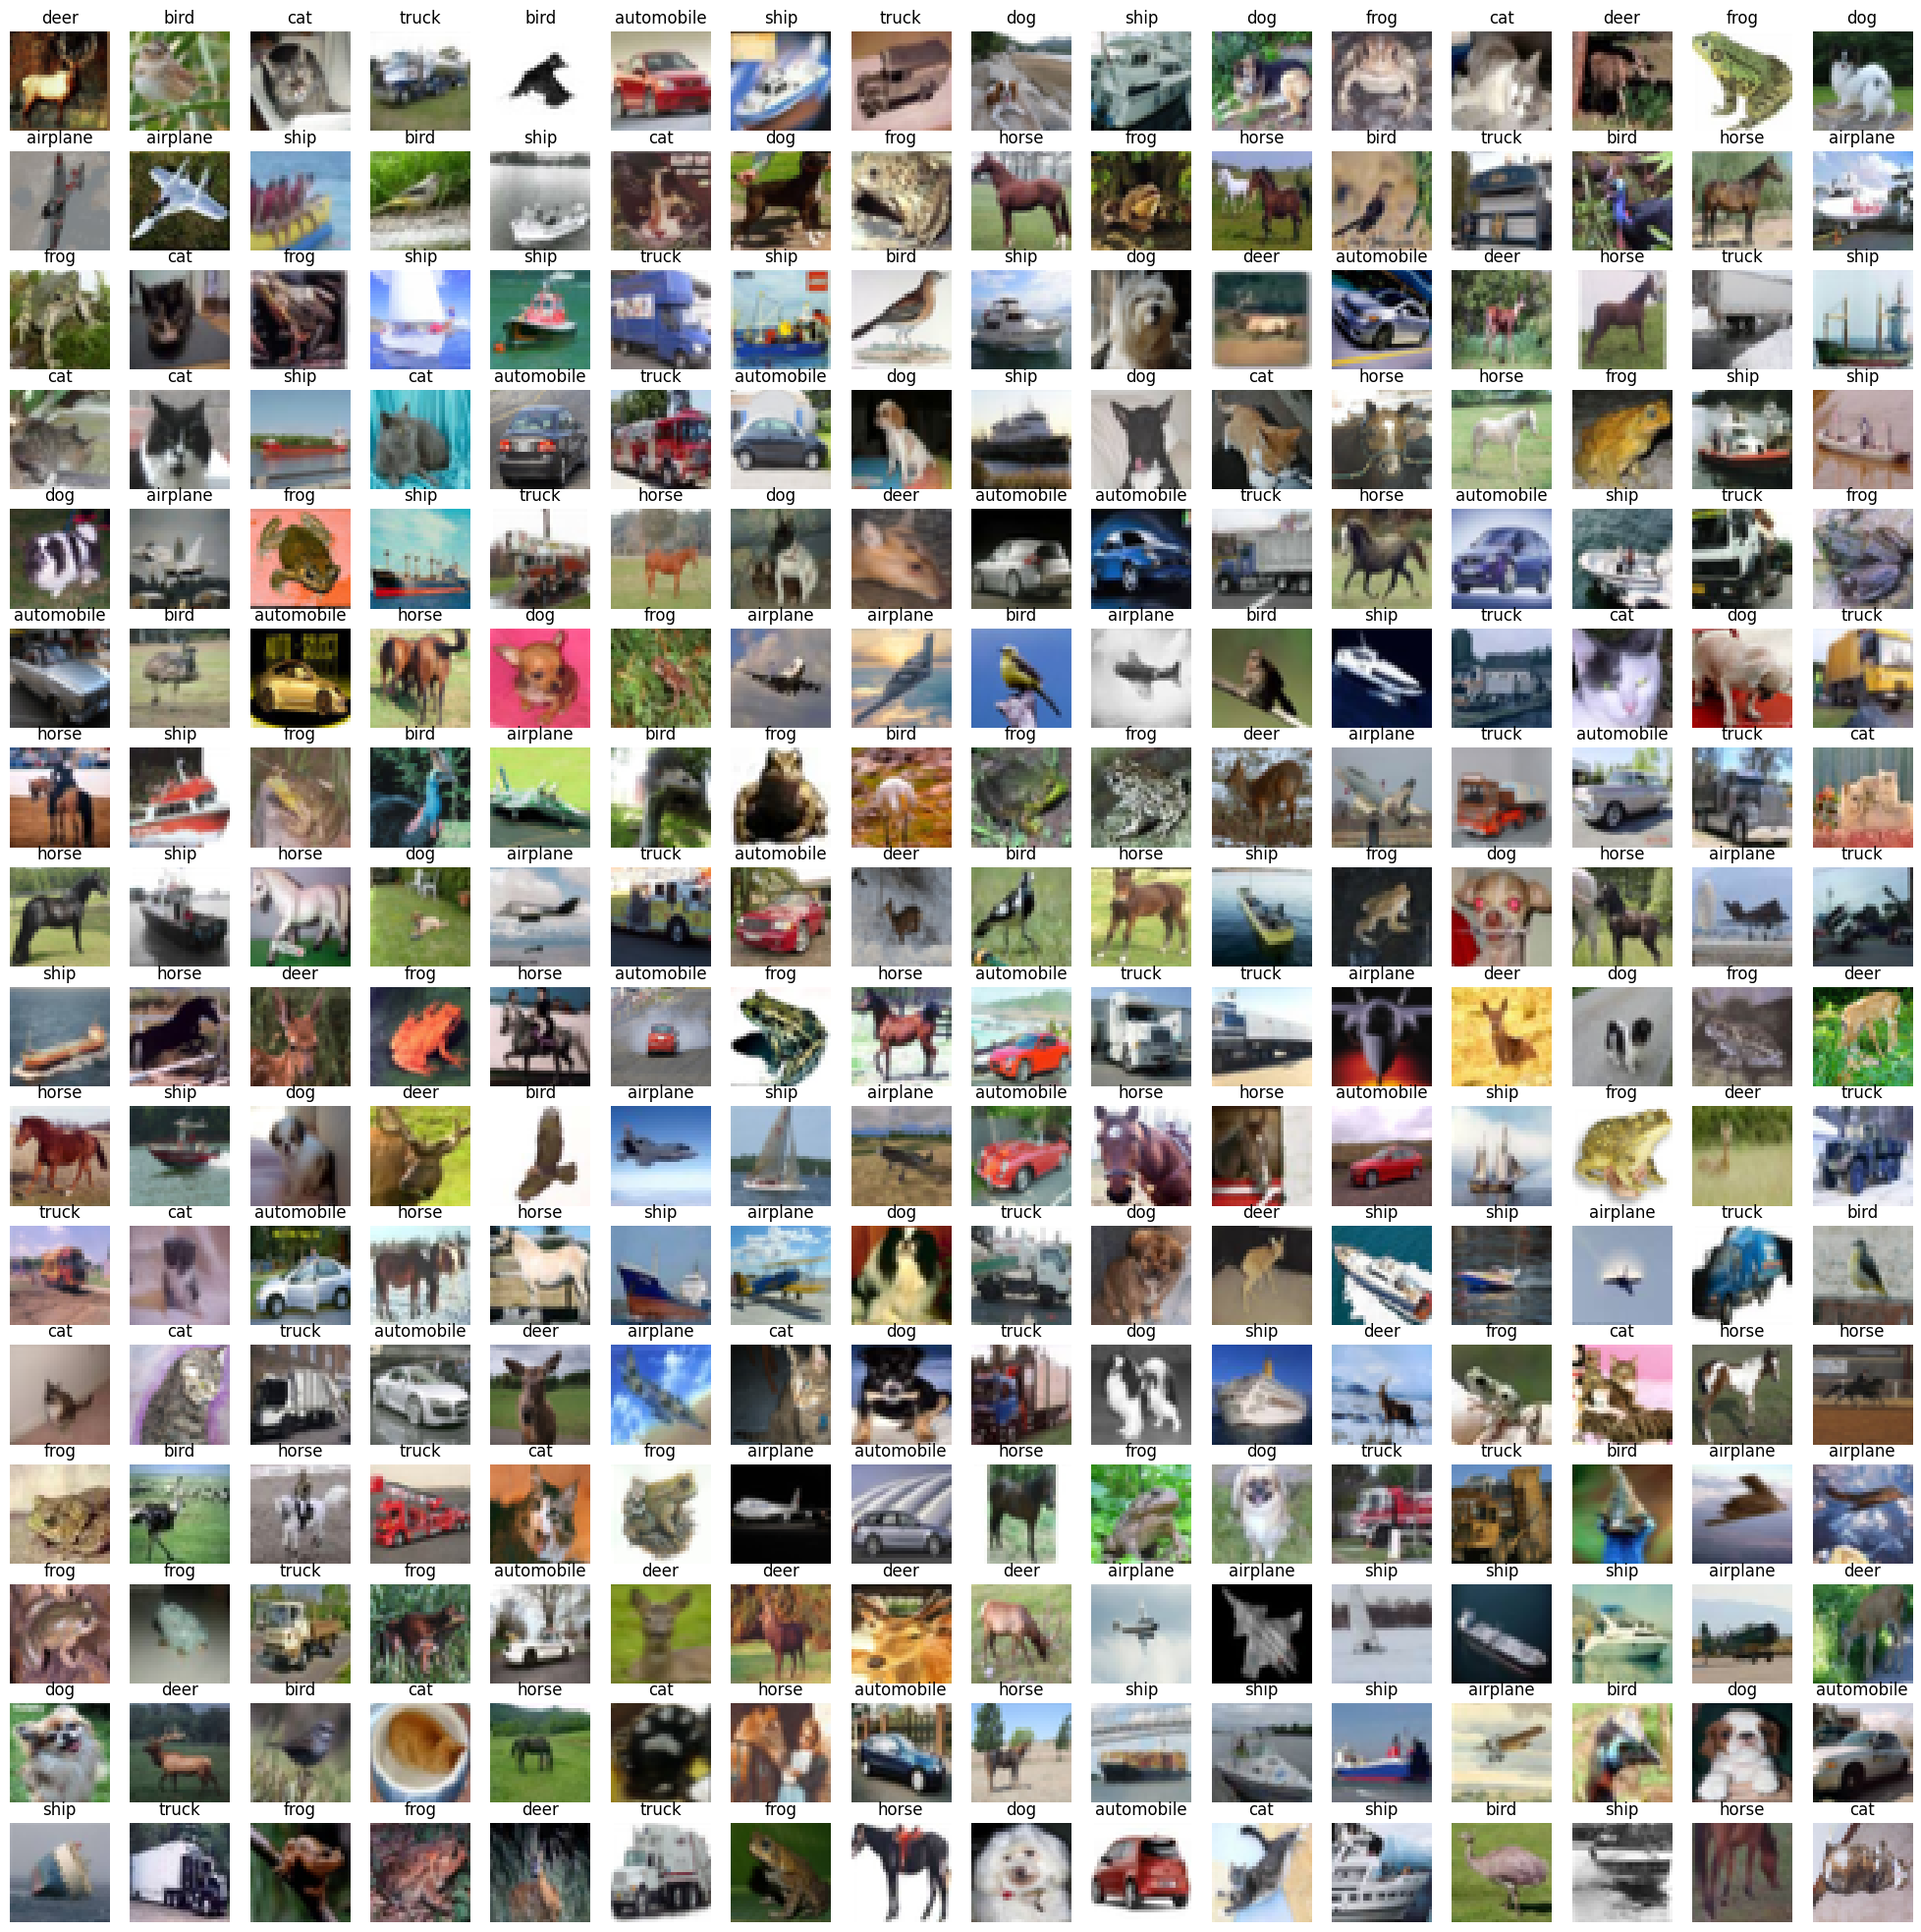

In [25]:
# Choose 256 examples from X_train data

plt.figure(figsize=(25, 25))
for i in range(256):
    rand_index = int(np.random.randint(low=0, high=50000, size=1))
    plt.subplot(16, 16, i+1)
    plt.axis('off')
    plt.title(classes[int(y_train[rand_index])])
    plt.imshow(X_train[rand_index])

## Data Preprocessing

In [26]:
X_train[5].min() # the smallest color code of image indexed 5

np.uint8(0)

In [27]:
X_train[5].max() # maximum color code of image indexed 5

np.uint8(252)

In [28]:
X_train.max()

np.uint8(255)

In [29]:
# Normalize image pixels
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train / 255.0
X_test = X_test / 255.0

In [30]:
X_train[5].min()

np.float32(0.0)

In [31]:
X_train[5].max()

np.float32(0.9882353)

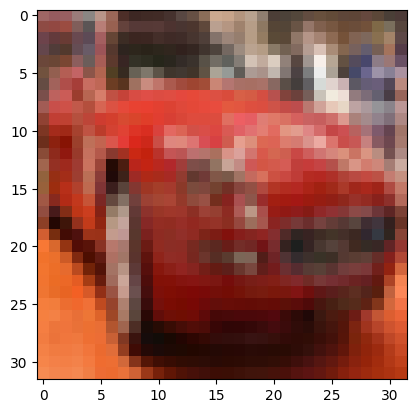

In [32]:
plt.imshow(X_train[5]);

### Check Format of X Data

In [33]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

* We have **4D Tensors**. It is good for CNN model.  

In [34]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

### Prepare "y" Data to CNN

Transforms **y** values to **vectoral** form.

For example:
3--->[0,0,0,1,0,0,0,0,0,0]


In [35]:
y_train[0] # Before

array([6], dtype=uint8)

**Why Categorical:**

* It speeds up the process.
* It prevents the model from behaving linearly.


In [36]:
from tensorflow.keras.utils import to_categorical

In [37]:
# starting from 0 to 9 there are 10 classes
Y_train = to_categorical(y_train, 10) # In the eval metrics (classification_report) section, we define the new variable as Y_train to use the original y_train value.
Y_test = to_categorical(y_test, 10)   #In the eval metrics section, we define the new variable as Y_test to use the original y_test value.
Y_test.shape

(10000, 10)

In [38]:
Y_train[0] # After

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

# CNN Model

## CNN Model 1 - Basic

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

![image.png](attachment:image.png)

In [40]:
model = Sequential()

# 1st convolutional layer
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=(32, 32, 3), activation='relu', padding='same')) # padding='same'

# 2nd convolutional layer
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# 3rd convolutional layer
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Fully Connecrted Layers
# Flatten
model.add(Flatten())

# ANN
# 1st hidden layer
model.add(Dense(128, activation='relu'))

# 2nd hidden layer
model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax')) # 10: class number, 'softmax' for multiclass

# Compile model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# kernel\_size=(3,3): Filter selection. The images should be in this format: input\_shape=(32, 32, 3).

# padding='same': The input data and the output will be the same - overlap.

# Here, 2 CONV + 1 Pool + 1 CONV + 1 Pool layers are used... we are experimenting.

# Similar structures are present in other Transfer Learning models as well.


An alternative sequential structure I got from Kaggle ([https://www.kaggle.com/code/zehraatlgan/cnn-for-cifar-10-image-classification](https://www.kaggle.com/code/zehraatlgan/cnn-for-cifar-10-image-classification)) — It was used as the last alternative at the bottom.

model = models.Sequential([

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),  
    layers.BatchNormalization(),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),  

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),  
    
    layers.Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.5),
    
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),  
    layers.Dropout(0.5),  
    
    layers.Dense(num_classes, activation='softmax')
])

![image.png](attachment:image.png)

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,034 (1.18 MB)

 Trainable params: 309,034 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

* We have **309,034 feature**

**Summary Explanation:**

In the **CNN (Convolutional Neural Network)** model, the **`model.summary()`** output displays the layers of the model, the output shape of each layer, and the number of parameters. Let's explain each layer and the parameter count:

**Layers and Outputs:**

1. **`conv2d (Conv2D)`**:

   * **Output Shape**: `(None, 32, 32, 32)`
   * **Number of Parameters**: **896**
   * **Explanation**: The first convolutional layer processes the input data using 32 filters of size 3x3. This layer learns basic visual features like edges and textures.

2. **`conv2d_1 (Conv2D)`**:

   * **Output Shape**: `(None, 32, 32, 64)`
   * **Number of Parameters**: **18,496**
   * **Explanation**: The second convolutional layer uses 64 filters of size 3x3 to learn more complex visual features.

3. **`max_pooling2d (MaxPooling2D)`**:

   * **Output Shape**: `(None, 16, 16, 64)`
   * **Number of Parameters**: **0**
   * **Explanation**: The max pooling layer uses a 2x2 pool to take the highest value from each region, reducing the image size by half (16x16x64). This layer creates a more abstract representation of the features.

4. **`conv2d_2 (Conv2D)`**:

   * **Output Shape**: `(None, 16, 16, 32)`
   * **Number of Parameters**: **18,464**
   * **Explanation**: The third convolutional layer uses 32 filters of size 3x3 to learn more complex features. The output size remains 16x16.

5. **`max_pooling2d_1 (MaxPooling2D)`**:

   * **Output Shape**: `(None, 8, 8, 32)`
   * **Number of Parameters**: **0**
   * **Explanation**: The second max pooling layer again reduces the image size by half (8x8x32).

6. **`flatten (Flatten)`**:

   * **Output Shape**: `(None, 2048)`
   * **Number of Parameters**: **0**
   * **Explanation**: This layer flattens the 2D data into 1D, allowing it to be passed to fully connected (dense) layers.

7. **`dense (Dense)`**:

   * **Output Shape**: `(None, 128)`
   * **Number of Parameters**: **262,272**
   * **Explanation**: The first fully connected layer receives 128 neurons. This layer learns features from all previous layers.

8. **`dense_1 (Dense)`**:

   * **Output Shape**: `(None, 64)`
   * **Number of Parameters**: **8,256**
   * **Explanation**: The second fully connected layer uses 64 neurons to learn more abstract features.

9. **`dense_2 (Dense)`**:

   * **Output Shape**: `(None, 10)`
   * **Number of Parameters**: **650**
   * **Explanation**: The final layer contains 10 neurons, with each neuron corresponding to a class. This layer provides the output for the model's classification task.

### Summary:

* **Total Number of Parameters**: 309,034 (1.18 MB)
* **Trainable Parameters**: 309,034
* **Non-Trainable Parameters**: 0

This model demonstrates the architecture of a CNN model used for classifying the **CIFAR-10** dataset. It consists of 3 convolutional layers, 2 max pooling layers, and 3 fully connected layers. These layers extract image features and perform classification. The total number of parameters in the model is 309,034, all of which are trainable.


In [42]:
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
early_stop = EarlyStopping(monitor='val_loss',patience=5)

In [44]:
model.fit(X_train, Y_train, batch_size=32, epochs=50, validation_data=(X_test,Y_test),callbacks=[early_stop])
# If you have a large data set, you should increase batch_size like 64.

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4968 - loss: 1.3982 - val_accuracy: 0.6155 - val_loss: 1.0893
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6599 - loss: 0.9662 - val_accuracy: 0.6809 - val_loss: 0.9187
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7164 - loss: 0.8072 - val_accuracy: 0.7179 - val_loss: 0.8194
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7507 - loss: 0.7073 - val_accuracy: 0.7119 - val_loss: 0.8409
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7781 - loss: 0.6314 - val_accuracy: 0.7250 - val_loss: 0.8107
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8009 - loss: 0.5628 - val_accuracy: 0.7269 - val_loss: 0.8301
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8219 - loss: 0.5030 - val_accuracy: 0.7258 - val_loss: 0.8723
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8414 - loss: 0.4433 -

* There is **overfitting**, since **accuracy 0.89 at train but 0.71 at test** data.

In [45]:
model.metrics_names

['loss', 'compile_metrics']

In [46]:
model.history.history

{'accuracy': [0.49678000807762146,
  0.6598799824714661,
  0.7164400219917297,
  0.7507200241088867,
  0.7781199812889099,
  0.8008800148963928,
  0.8218799829483032,
  0.8413800001144409,
  0.856719970703125,
  0.8741199970245361],
 'loss': [1.398155927658081,
  0.9661697149276733,
  0.8071745038032532,
  0.7073156833648682,
  0.6313912868499756,
  0.5627650618553162,
  0.503002405166626,
  0.44330188632011414,
  0.4014992117881775,
  0.3512289822101593],
 'val_accuracy': [0.6154999732971191,
  0.680899977684021,
  0.7178999781608582,
  0.711899995803833,
  0.7250000238418579,
  0.7268999814987183,
  0.7257999777793884,
  0.7303000092506409,
  0.7189000248908997,
  0.7210000157356262],
 'val_loss': [1.0893476009368896,
  0.9186515808105469,
  0.819355845451355,
  0.8409119248390198,
  0.8106522560119629,
  0.830137312412262,
  0.8722791075706482,
  0.9287399649620056,
  0.9614760875701904,
  0.9693747758865356]}

In [47]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.49678,1.398156,0.6155,1.089348
1,0.65988,0.966170,0.6809,0.918652
2,0.71644,0.807175,0.7179,0.819356
3,0.75072,0.707316,0.7119,0.840912
4,0.77812,0.631391,0.7250,0.810652


In [48]:
summary.tail()

,accuracy,loss,val_accuracy,val_loss
5,0.80088,0.562765,0.7269,0.830137
6,0.82188,0.503002,0.7258,0.872279
7,0.84138,0.443302,0.7303,0.928740
8,0.85672,0.401499,0.7189,0.961476
9,0.87412,0.351229,0.7210,0.969375


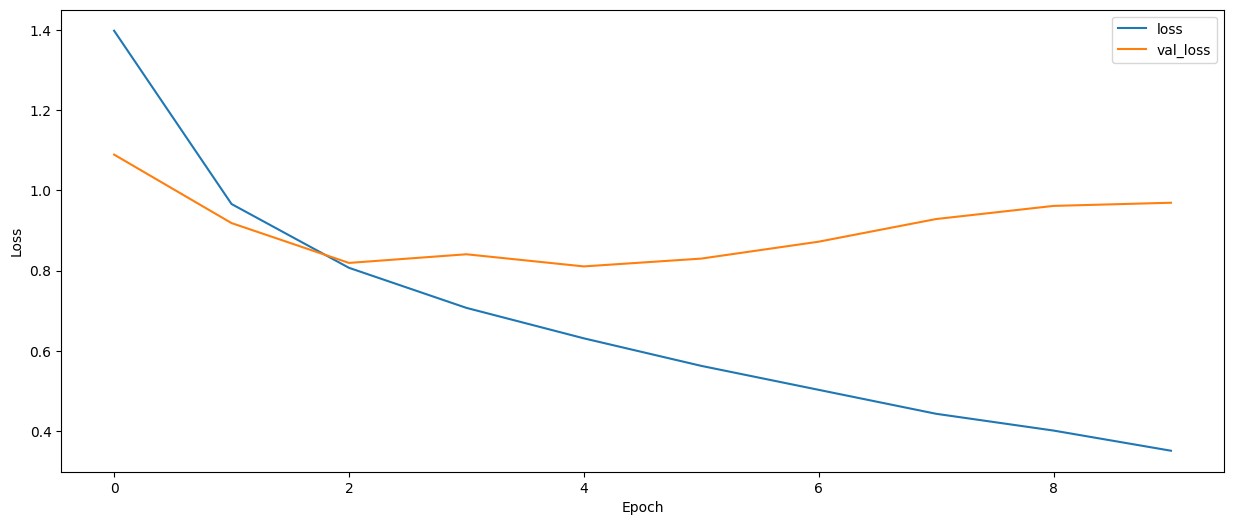

In [49]:
plt.figure(figsize=(15, 6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

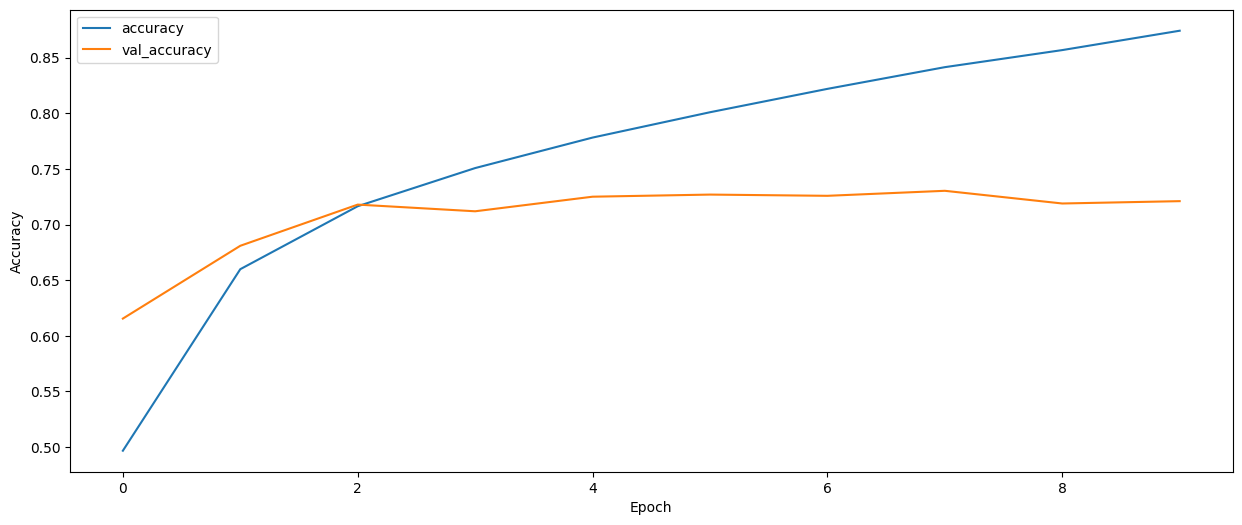

In [50]:
plt.figure(figsize=(15, 6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

* According to these figures **2 Epoch** is adequate.  

### Eval Metrics

In [51]:
print(model.evaluate(X_test, Y_test, verbose=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7210 - loss: 0.9694
[0.9693747758865356, 0.7210000157356262]


In [52]:
preds = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [53]:
predictions = np.argmax(preds, axis=1)

In [54]:
predictions

array([3, 8, 1, ..., 5, 4, 7])

In [55]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
#y_test = np.argmax(y_test, axis=1)

In [56]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.79      0.71      0.75      1000
           1       0.84      0.85      0.85      1000
           2       0.66      0.54      0.60      1000
           3       0.48      0.60      0.54      1000
           4       0.63      0.75      0.69      1000
           5       0.67      0.57      0.62      1000
           6       0.78      0.79      0.78      1000
           7       0.78      0.74      0.76      1000
           8       0.81      0.85      0.83      1000
           9       0.82      0.81      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



In [57]:
print(confusion_matrix(y_test, predictions))

[[712  19  49  45  22   3  11  16  82  41]
 [ 13 848   4  11   4   1   6   4  33  76]
 [ 61   7 540  84 127  59  60  43  15   4]
 [ 15  12  48 598  75 135  57  32  12  16]
 [  7   6  37  76 746  15  58  44   9   2]
 [  7   3  47 244  53 573  13  46   7   7]
 [  5   3  38  90  43  18 785   5   9   4]
 [ 12   4  35  47  91  46   5 743   6  11]
 [ 47  27  11  19   7   1   7   6 855  20]
 [ 28  77   6  21   8   4   3  14  29 810]]


In [58]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.9693747758865356
Test accuracy: 0.7210000157356262


* **Accuracy = 0.71**, low.

### Get a Prediction

In [71]:
my_image = X_test[4]

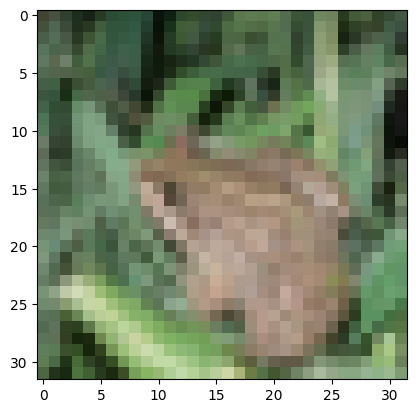

In [72]:
plt.imshow(my_image)

In [73]:
image_prediction = model.predict(my_image.reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [74]:
image_prediction

array([[1.97096686e-08, 2.13805311e-06, 1.21373978e-05, 1.07248576e-04,
        7.20213802e-06, 4.91092294e-07, 9.99870777e-01, 1.85459426e-09,
        1.25002708e-09, 4.30646558e-08]], dtype=float32)

In [75]:
np.argmax(image_prediction, axis=1)

array([6])

In [76]:
result=np.argmax(image_prediction, axis=1)

In [77]:
result

array([6])

In [78]:
classes[int(result)]

'frog'

In [ ]:
#model.save("cnn-2.h5")

**Class names:**

- 0: Airplane
- 1: Automobile
- 2: Bird
- 3: Cat
- 4: Deer
- 5: Dog
- 6: Frog
- 7: Horse
- 8: Ship
- 9: Truck

![image.png](attachment:image.png)

## CNN Model 2 - Add Dropout and EarlyStopping to CNN model

In [79]:
early_stop = EarlyStopping(monitor='val_loss', patience=15)

In [80]:
model= Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3), padding='same'))

model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu', padding='same'))
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.4)) # adding dropout layer

model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu')) # We increased filter number by following best practice
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.4)) # adding dropout layer

model.add(Flatten())
model.add(Dense(256, activation='relu')) # We gave 256 neuron in a one ANN layer
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [81]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,706 (6.49 MB)

 Trainable params: 1,701,706 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

* We have **1,701,706 parameter**.  Number of parameter increased 300K to 1,7M.

In [82]:
model.fit(X_train, Y_train, batch_size=32, epochs=100, validation_data=(X_test,Y_test), callbacks=[early_stop])

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.5016 - loss: 1.3767 - val_accuracy: 0.6196 - val_loss: 1.0687
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6615 - loss: 0.9633 - val_accuracy: 0.7143 - val_loss: 0.8345
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7121 - loss: 0.8159 - val_accuracy: 0.7217 - val_loss: 0.7982
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7470 - loss: 0.7211 - val_accuracy: 0.7532 - val_loss: 0.7164
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7719 - loss: 0.6519 - val_accuracy: 0.7524 - val_loss: 0.7152
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7908 - loss: 0.5957 - val_accuracy: 0.7648 - val_loss: 0.6802
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8059 - loss: 0.5501 - val_accuracy: 0.7668 - val_loss: 0.6913
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8211 - loss

In [83]:
model.history.history

{'accuracy': [0.501579999923706,
  0.6614999771118164,
  0.7120800018310547,
  0.7470399737358093,
  0.7719399929046631,
  0.7907800078392029,
  0.8058800101280212,
  0.8210800290107727,
  0.8334400057792664,
  0.8396999835968018,
  0.849839985370636,
  0.8604000210762024,
  0.8668799996376038,
  0.8726000189781189,
  0.8762000203132629,
  0.884119987487793,
  0.8881400227546692,
  0.89274001121521,
  0.8960000276565552,
  0.9000800251960754,
  0.9028199911117554],
 'loss': [1.376673698425293,
  0.963253915309906,
  0.8159211874008179,
  0.7210938930511475,
  0.6519489288330078,
  0.5957030057907104,
  0.5500673651695251,
  0.5068372488021851,
  0.4739665985107422,
  0.44674238562583923,
  0.4176580011844635,
  0.392202228307724,
  0.37115585803985596,
  0.3611392676830292,
  0.3487928807735443,
  0.32172778248786926,
  0.31636056303977966,
  0.30545124411582947,
  0.2971799671649933,
  0.28220465779304504,
  0.2814091742038727],
 'val_accuracy': [0.6195999979972839,
  0.71429997682571

In [84]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.50158,1.376674,0.6196,1.068693
1,0.66150,0.963254,0.7143,0.834496
2,0.71208,0.815921,0.7217,0.798207
3,0.74704,0.721094,0.7532,0.716432
4,0.77194,0.651949,0.7524,0.715200


In [85]:
summary.tail()

,accuracy,loss,val_accuracy,val_loss
16,0.88814,0.316361,0.7726,0.761935
17,0.89274,0.305451,0.7773,0.761223
18,0.89600,0.297180,0.7777,0.782620
19,0.90008,0.282205,0.7784,0.791302
20,0.90282,0.281409,0.7732,0.806315


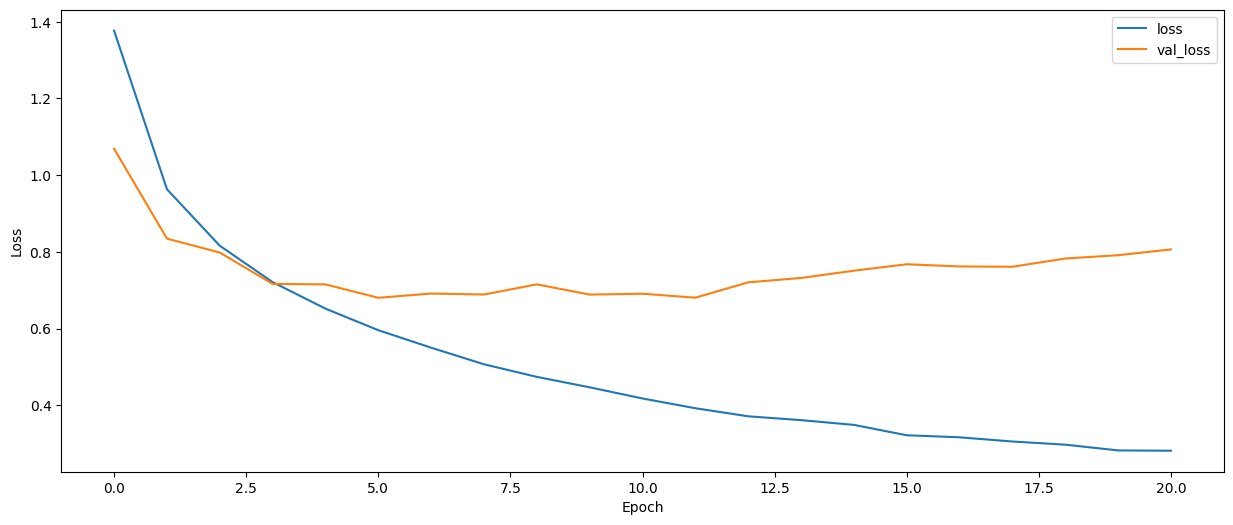

In [86]:
plt.figure(figsize=(15, 6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

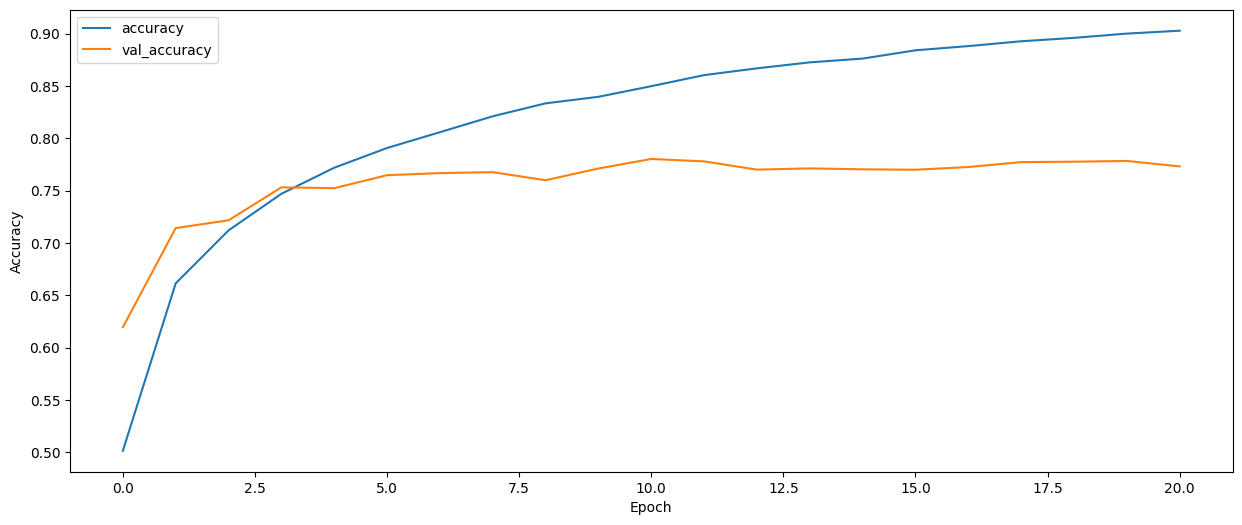

In [87]:
plt.figure(figsize=(15, 6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [88]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.8063149452209473
Test accuracy: 0.7731999754905701


### Eval Metrics

In [89]:
preds = model.predict(X_test)
predictions= np.argmax(preds, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [90]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1000
           1       0.88      0.89      0.88      1000
           2       0.69      0.66      0.67      1000
           3       0.61      0.53      0.57      1000
           4       0.74      0.75      0.75      1000
           5       0.65      0.73      0.69      1000
           6       0.75      0.88      0.81      1000
           7       0.83      0.82      0.83      1000
           8       0.89      0.85      0.87      1000
           9       0.86      0.86      0.86      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



* **Accuracy increased 0.71  to 0.77**. But, still low.

In [91]:
print(confusion_matrix(y_test, predictions))

[[772  15  63  24  12  10  11   7  51  35]
 [  7 887   6   3   1   4  10   1  17  64]
 [ 49   3 655  54  83  58  67  24   3   4]
 [ 20   8  61 527  56 204  88  24   5   7]
 [ 10   3  52  44 746  37  56  45   5   2]
 [ 14   3  32 119  29 733  26  37   4   3]
 [  5   3  34  24  26  19 878   8   2   1]
 [  5   1  21  38  44  59   7 820   0   5]
 [ 35  23  20  17   3   8  19   4 850  21]
 [ 14  59   6  13   2   4  10  13  15 864]]


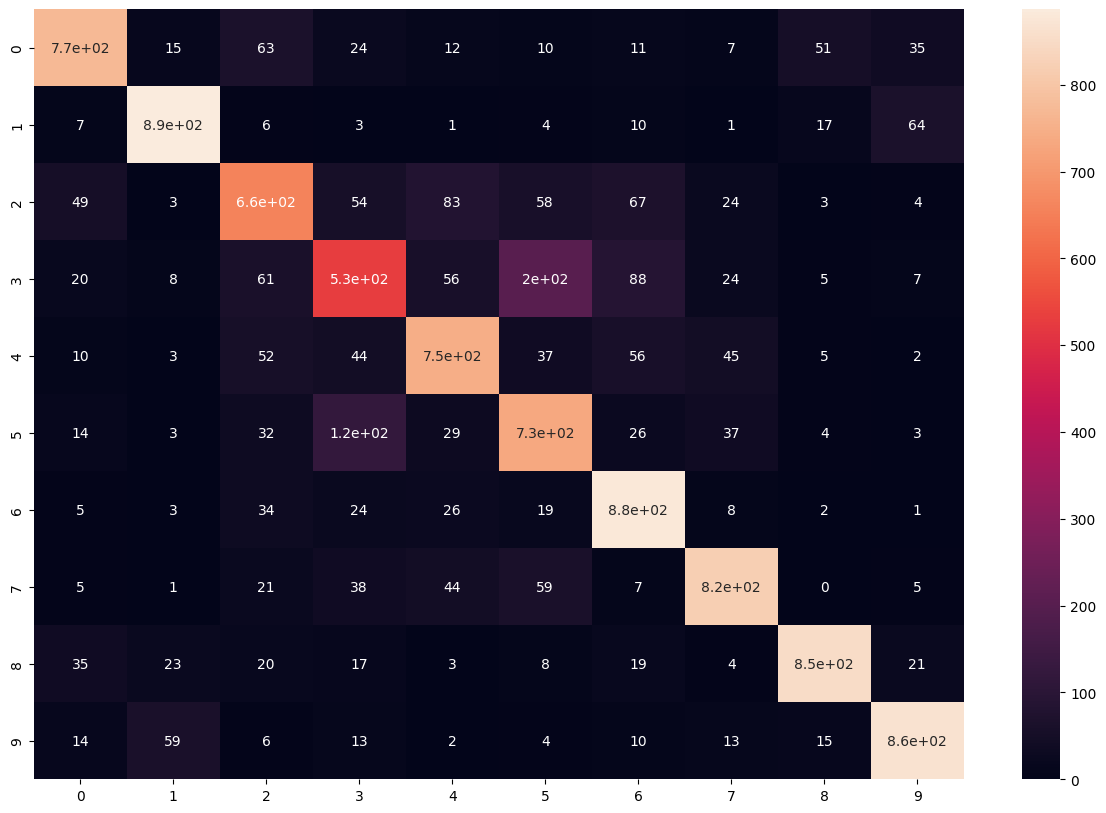

In [92]:
plt.figure(figsize=(15,10))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True);

![image.png](attachment:image.png)

## CNN Model 3 - Increased Conv Layers,  Add BatchNormalization, exclude Dropout

In [93]:
from tensorflow.keras.layers import BatchNormalization

In [94]:
early_stop = EarlyStopping(monitor='val_loss',patience=10)

In [95]:
model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
# model.add(Dropout(0.3))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
#model.add(Dropout(0.5))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
#model.add(Dropout(0.5))

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
#model.add(Dropout(0.5))


model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
#model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))    # num_classes = 10

# Checking the model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             

 Total params: 1,474,218 (5.62 MB)

 Trainable params: 1,471,530 (5.61 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [96]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [97]:
model.fit(X_train, Y_train, batch_size=32, epochs=100, validation_data=(X_test,Y_test), callbacks=[early_stop])

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.4830 - loss: 1.5164 - val_accuracy: 0.6048 - val_loss: 1.1594
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6937 - loss: 0.8997 - val_accuracy: 0.6861 - val_loss: 0.9210
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7601 - loss: 0.7234 - val_accuracy: 0.7478 - val_loss: 0.7494
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7983 - loss: 0.6062 - val_accuracy: 0.6979 - val_loss: 0.8994
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8335 - loss: 0.5030 - val_accuracy: 0.7607 - val_loss: 0.7289
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8632 - loss: 0.4141 - val_accuracy: 0.7972 - val_loss: 0.6180
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8938 - loss: 0.3251 - val_accuracy: 0.8230 - val_loss: 0.5701
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9125 

In [98]:
model.history.history

{'accuracy': [0.48298001289367676,
  0.6936600208282471,
  0.7601000070571899,
  0.7983400225639343,
  0.8334599733352661,
  0.8631799817085266,
  0.8938000202178955,
  0.9125000238418579,
  0.9272800087928772,
  0.9420400261878967,
  0.9503800272941589,
  0.9589800238609314,
  0.9617000222206116,
  0.9651600122451782,
  0.9699000120162964,
  0.970740020275116,
  0.9742799997329712],
 'loss': [1.5164467096328735,
  0.8997389078140259,
  0.7233730554580688,
  0.6061713099479675,
  0.5029752850532532,
  0.41407522559165955,
  0.32505002617836,
  0.26673662662506104,
  0.2173243761062622,
  0.1733810156583786,
  0.14859730005264282,
  0.12411992251873016,
  0.11384600400924683,
  0.10545626282691956,
  0.09188340604305267,
  0.08781905472278595,
  0.07718140631914139],
 'val_accuracy': [0.6047999858856201,
  0.6861000061035156,
  0.7477999925613403,
  0.6978999972343445,
  0.760699987411499,
  0.7972000241279602,
  0.8230000138282776,
  0.8029000163078308,
  0.828499972820282,
  0.8248999

In [99]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.48298,1.516447,0.6048,1.159364
1,0.69366,0.899739,0.6861,0.921006
2,0.76010,0.723373,0.7478,0.749350
3,0.79834,0.606171,0.6979,0.899421
4,0.83346,0.502975,0.7607,0.728945


In [100]:
summary.tail()

,accuracy,loss,val_accuracy,val_loss
12,0.96170,0.113846,0.8218,0.701840
13,0.96516,0.105456,0.8172,0.723786
14,0.96990,0.091883,0.8309,0.701585
15,0.97074,0.087819,0.8212,0.768130
16,0.97428,0.077181,0.8309,0.748048


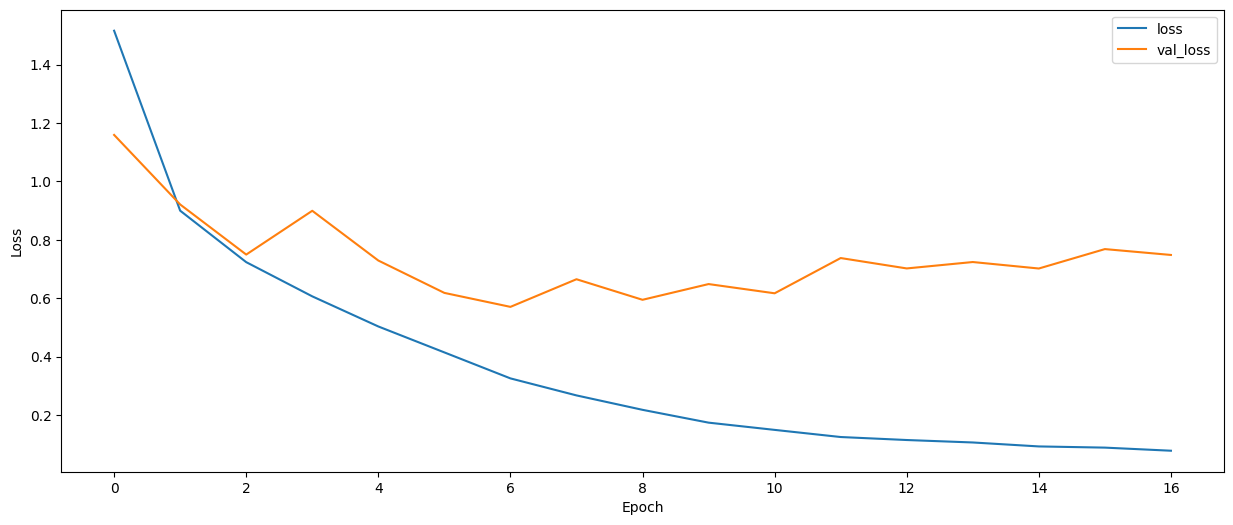

In [101]:
plt.figure(figsize=(15, 6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

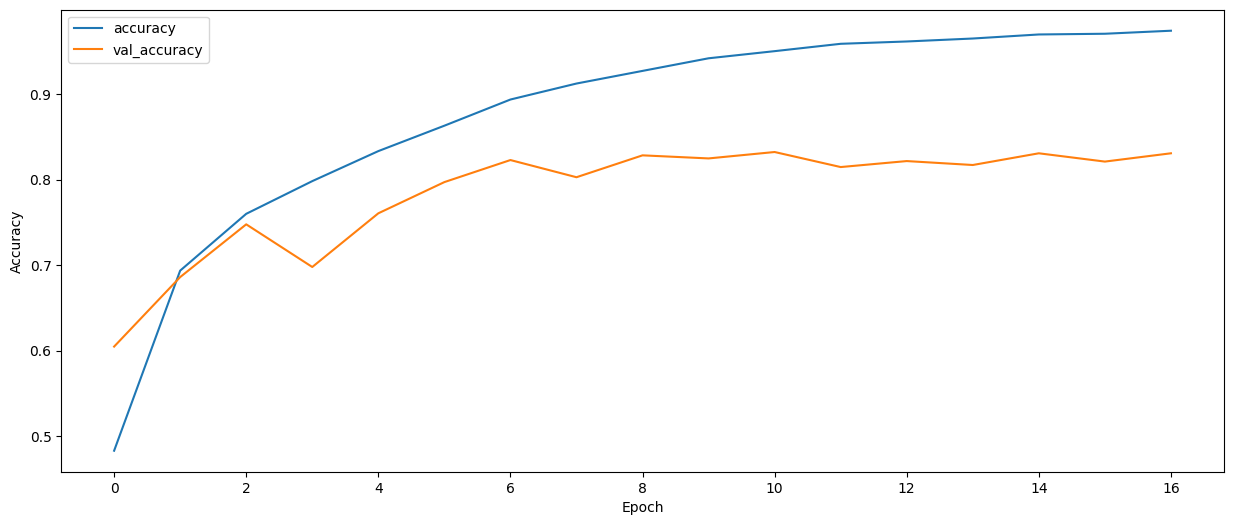

In [102]:
plt.figure(figsize=(15, 6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

###  Eval Metrics

In [103]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.7480475306510925
Test accuracy: 0.8309000134468079


In [104]:
preds = model.predict(X_test)
predictions= np.argmax(preds, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [105]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1000
           1       0.91      0.95      0.93      1000
           2       0.74      0.76      0.75      1000
           3       0.66      0.70      0.68      1000
           4       0.84      0.78      0.81      1000
           5       0.79      0.73      0.76      1000
           6       0.84      0.89      0.86      1000
           7       0.86      0.87      0.87      1000
           8       0.89      0.92      0.90      1000
           9       0.92      0.89      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



* **Accuracy increased 0.77 to 0.84**.  

* As you can see, if we increase number of Conv layers, filters, hidden layers and neurons, model's succes level can/may increase.

* We can say that **increasing the number of convolutional layers, filters, hidden layers, and neurons in colour images increases the model's success**.

* If you meet **overfitting** problem, you can **activate "dropouts"**.

## CNN Model 4 - Increased Conv Layers,  Add BatchNormalization, include Dropout

![image.png](attachment:image.png)

In [106]:
early_stop = EarlyStopping(monitor='val_loss',patience=10)
model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.3)) # can be changed to 0.25

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.5)) # can be changed to 0.25

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.5)) # can be changed to 0.25

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.5)) # can be changed to 0.25


model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5)) # can be changed to 0.25

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5)) # can be changed to 0.25
model.add(Dense(10, activation='softmax'))    # num_classes = 10

# Checking the model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,474,218 (5.62 MB)

 Trainable params: 1,471,530 (5.61 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [107]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [108]:
model.fit(X_train, Y_train, batch_size=32, epochs=100, validation_data=(X_test,Y_test), callbacks=[early_stop])

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 20ms/step - accuracy: 0.3358 - loss: 1.8858 - val_accuracy: 0.3293 - val_loss: 2.0112
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5191 - loss: 1.3359 - val_accuracy: 0.5423 - val_loss: 1.2673
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6031 - loss: 1.1334 - val_accuracy: 0.6586 - val_loss: 0.9468
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6564 - loss: 0.9993 - val_accuracy: 0.7068 - val_loss: 0.8476
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6912 - loss: 0.9087 - val_accuracy: 0.7588 - val_loss: 0.7053
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7200 - loss: 0.8344 - val_accuracy: 0.7713 - val_loss: 0.6757
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.7409 - loss: 0.7779 - val_accuracy: 0.7796 - val_loss: 0.6444
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7

In [109]:
model.history.history

{'accuracy': [0.33583998680114746,
  0.51910001039505,
  0.6030600070953369,
  0.6563599705696106,
  0.6911799907684326,
  0.719980001449585,
  0.7408599853515625,
  0.757099986076355,
  0.7691599726676941,
  0.7787200212478638,
  0.7901399731636047,
  0.7953799962997437,
  0.8035600185394287,
  0.8111199736595154,
  0.8174600005149841,
  0.8234800100326538,
  0.8274800181388855,
  0.8323400020599365,
  0.8370199799537659,
  0.8403400182723999,
  0.8436999917030334,
  0.8468800187110901,
  0.8494200110435486,
  0.853380024433136,
  0.8554400205612183,
  0.857699990272522,
  0.8615800142288208,
  0.8624399900436401,
  0.8650000095367432,
  0.8680999875068665,
  0.8714200258255005,
  0.8744999766349792,
  0.8725799918174744,
  0.876800000667572,
  0.876479983329773,
  0.8794400095939636,
  0.8787599802017212,
  0.8820000290870667,
  0.8848999738693237,
  0.8848599791526794,
  0.88646000623703,
  0.8877999782562256,
  0.887660026550293,
  0.8918399810791016,
  0.8913400173187256,
  0.8938

In [110]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.33584,1.885787,0.3293,2.011241
1,0.51910,1.335853,0.5423,1.267317
2,0.60306,1.133359,0.6586,0.946824
3,0.65636,0.999298,0.7068,0.847646
4,0.69118,0.908706,0.7588,0.705324


In [111]:
summary.tail()

,accuracy,loss,val_accuracy,val_loss
50,0.89980,0.302590,0.8706,0.406225
51,0.90078,0.298953,0.8692,0.418021
52,0.90098,0.293860,0.8733,0.407917
53,0.90086,0.294875,0.8739,0.405490
54,0.90424,0.284159,0.8751,0.405216


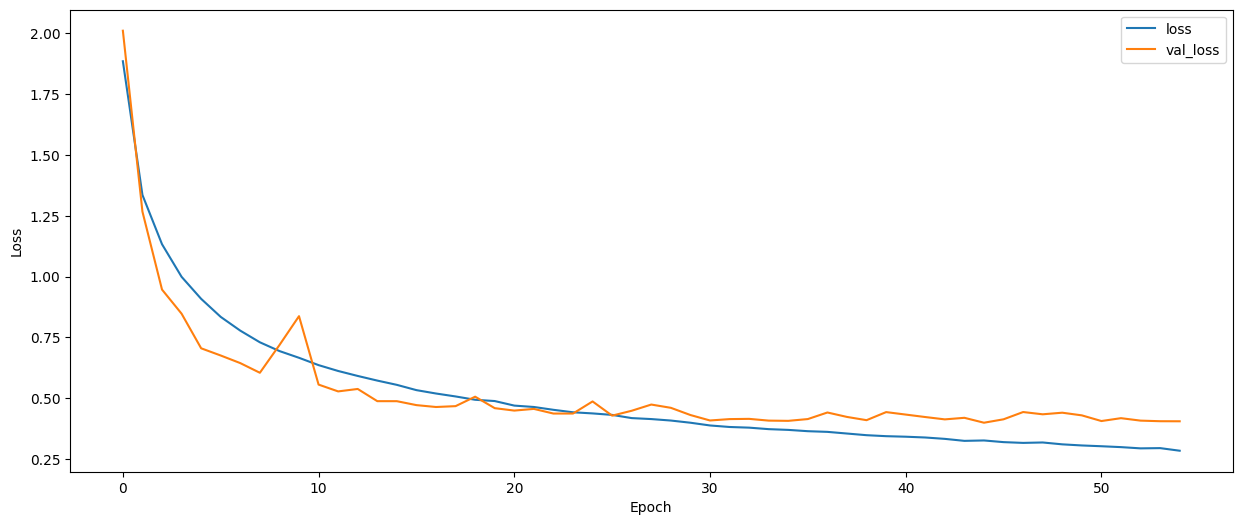

In [112]:
plt.figure(figsize=(15, 6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

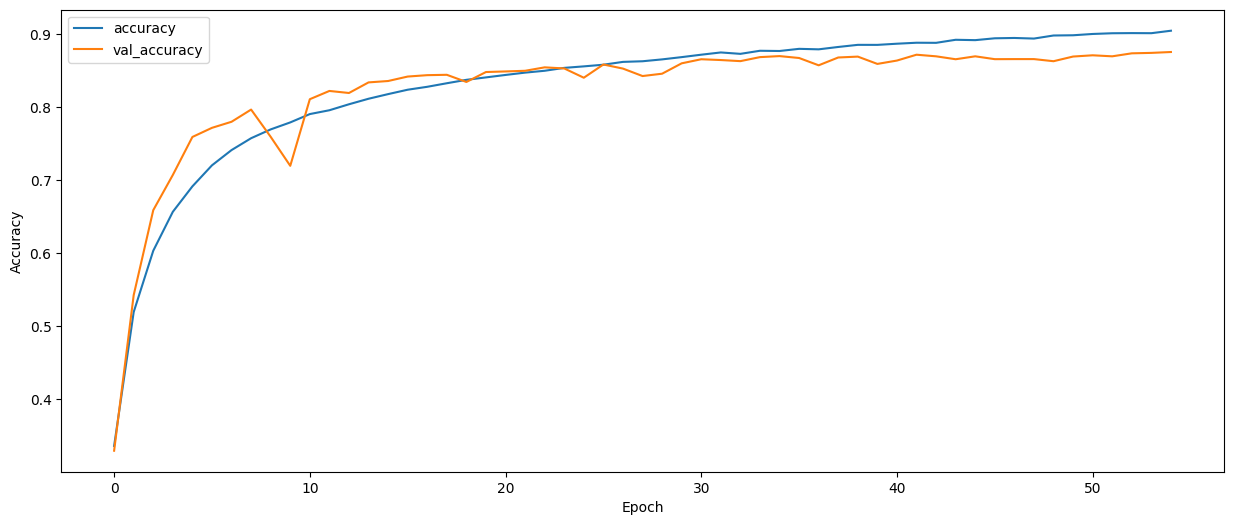

In [113]:
plt.figure(figsize=(15, 6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

###  Eval Metrics

In [114]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.4052157998085022
Test accuracy: 0.8751000165939331


In [115]:
preds = model.predict(X_test)
predictions= np.argmax(preds, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [116]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1000
           1       0.94      0.95      0.94      1000
           2       0.87      0.79      0.83      1000
           3       0.81      0.69      0.74      1000
           4       0.86      0.86      0.86      1000
           5       0.78      0.83      0.81      1000
           6       0.86      0.94      0.90      1000
           7       0.88      0.93      0.91      1000
           8       0.93      0.94      0.93      1000
           9       0.93      0.93      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.87      0.88      0.87     10000
weighted avg       0.87      0.88      0.87     10000



In [117]:
print(confusion_matrix(y_test, predictions))

[[892   9  16   7   6   1   6  13  43   7]
 [  4 946   0   0   2   2   2   0  10  34]
 [ 43   0 793  25  43  30  38  23   2   3]
 [ 10   4  39 685  32 146  50  19   5  10]
 [  7   2  27  21 865  26  27  24   1   0]
 [  6   0  17  72  23 835  11  32   2   2]
 [  4   1  14  18   9  11 935   5   2   1]
 [  5   1   5  10  23  17   2 932   1   4]
 [ 27   8   2   3   3   1   3   4 936  13]
 [ 10  36   0   3   0   1   7   3   8 932]]


* **Accuracy increased 0.83 to 0.87**.  

* As you can see, if we increase number of Conv layers, filters, hidden layers and neurons, model's succes level can/may increase.

* We can say that **increasing the number of convolutional layers, filters, hidden layers, and neurons in colour images increases the model's success**.

*  **activating "dropouts"** eliminated the overfitting problem, we can try reducing the rate of dropouts from 0.5 to 0.25.